In [1]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

print("Loading data... ⌛")
fashion_mnist = tf.keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"Training Data Shape: {train_images.shape}")
print(f"Number of Labels: {len(train_labels)}")

Loading data... ⌛
Training Data Shape: (60000, 28, 28)
Number of Labels: 60000


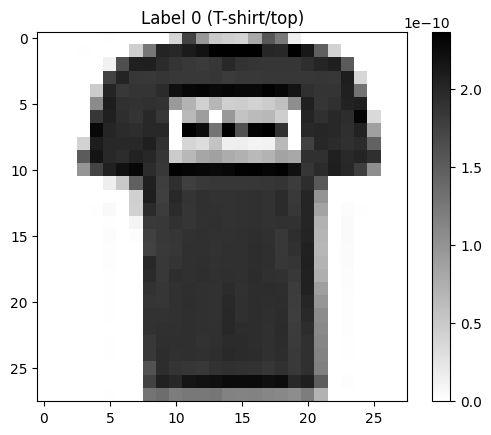

In [6]:
# تجهيز الأرقام
train_images = train_images / 255.0
test_images = test_images / 255.0

# رسم صورة للتأكد
plt.figure()
plt.imshow(train_images[1], cmap=plt.cm.binary)
plt.colorbar()
plt.grid(False)
plt.title(f"Label {train_labels[1]} ({class_names[train_labels[1]]})")
plt.show()

In [ ]:
model = tf.keras.Sequential([
  tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
  tf.keras.layers.MaxPooling2D((2, 2)),

  tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
  tf.keras.layers.MaxPooling2D((2, 2)),

  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(64, activation='relu'),
  tf.keras.layers.Dense(10)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

print("Model Built Seccessfully! ✅")

c:\Users\Hp\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model Built Seccessfully! ✅


In [9]:
print("\nStarting Training... 🚀")

history = model.fit(train_images, train_labels, epochs=10)

print("Training Finished! ✅")

test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f"\nTest Accuracy: {test_acc*100:.2f}%")

# هنحفظ الموديل عشان هنحتاجه لما نعلي الليفل
model.save('fashion_model.h5')
print("Model Saved Successfully! 📁")


Starting Training... 🚀
Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 85s 45ms/step - accuracy: 0.0998 - loss: 2.3028
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 79s 42ms/step - accuracy: 0.0989 - loss: 2.3028
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 80s 43ms/step - accuracy: 0.0978 - loss: 2.3028
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 43ms/step - accuracy: 0.0979 - loss: 2.3028
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 44ms/step - accuracy: 0.0966 - loss: 2.3028
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 82s 44ms/step - accuracy: 0.0988 - loss: 2.3028
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 83s 44ms/step - accuracy: 0.0985 - loss: 2.3028
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 85s 45ms/step - accuracy: 0.0981 - loss: 2.3028
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 45ms/step - accuracy: 0.0995 - loss: 2.3028
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 144s 46ms/step - accuracy: 0.0966 - loss: 2.3028
Training Finished! ✅
313/313 - 4s - 14ms/step - accuracy: 0.1000 - loss: 2


Test Accuracy: 10.00%
Model Saved Successfully! 📁


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step


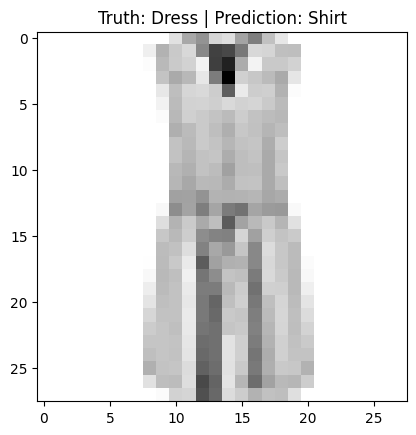

In [11]:
img_index = 75
img = test_images[img_index]
label = test_labels[img_index]

predictions = model.predict(np.array([img]))
predicted_label = np.argmax(predictions)

plt.figure()
plt.imshow(img, cmap=plt.cm.binary)
plt.title(f"Truth: {class_names[label]} | Prediction: {class_names[predicted_label]}")
plt.show()